🌸 Flower Image Classification with Transfer Learning (MobileNetV2)

## Overview

This project implements an end-to-end image classification pipeline to identify 102 flower categories from the Oxford Flowers dataset. It covers the complete workflow, including data preprocessing, model training, evaluation, and inference.

A pretrained MobileNetV2 model is leveraged using transfer learning and adapted for this multi-class classification task.

### Objectives

- Prepare and preprocess image data for deep learning models  
- Apply transfer learning using a pretrained CNN architecture  
- Train and evaluate a multi-class image classifier  
- Perform predictions on unseen images  

### Scope

The project focuses on building a complete deep learning pipeline from data loading to inference. It demonstrates practical implementation of transfer learning and model evaluation, with scope for further improvements such as hyperparameter tuning and deployment.

In [1]:
# Setup

import warnings
warnings.filterwarnings("ignore")

import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.datasets import Flowers102
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0


In [2]:
from pathlib import Path

# Base directory
BASE_DIR = Path("..")

# Data paths
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## Dataset Preparation

The [Oxford Flowers 102](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.Flowers102.html) dataset is used for image classification and is split into **training**, **validation**, and **test** sets.

All images are resized to **224 × 224**, converted to tensors, and normalized using ImageNet statistics to match the input requirements of pretrained models such as MobileNetV2.

In [3]:
# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
# Load datasets
train_dataset = Flowers102(
    root=DATA_DIR,
    split="train",
    transform=transform,
    download=True
)

val_dataset = Flowers102(
    root=DATA_DIR,
    split="val",
    transform=transform,
    download=True
)

test_dataset = Flowers102(
    root=DATA_DIR,
    split="test",
    transform=transform,
    download=True
)

## Data Exploration

The dataset is examined to understand its size and structure, ensuring it is loaded correctly and ready for model training.

In [5]:
# Dataset overview
datasets = {
    "train": train_dataset,
    "val": val_dataset,
    "test": test_dataset
}

print("Dataset sizes:")
for split, dataset in datasets.items():
    print(f"{split}: {len(dataset)} samples")

total_train_samples = len(train_dataset)
print(f"\nTotal training samples: {total_train_samples}")

Dataset sizes:
train: 1020 samples
val: 1020 samples
test: 6149 samples

Total training samples: 1020


In [6]:
# Number of classes
num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")

# Sample class names
print(train_dataset.classes[:5])

Number of classes: 102
['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold']


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8781512..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].


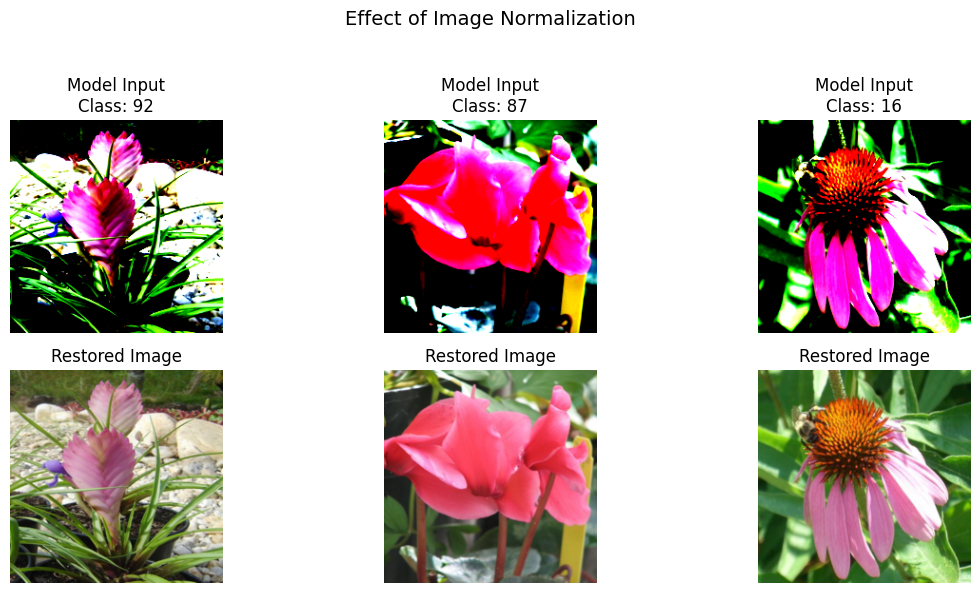

In [7]:
# Visualization: Model Input vs Restored Image
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

indices = random.sample(range(len(train_dataset)), 3)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i, idx in enumerate(indices):
    image, label = train_dataset[idx]

    image_np = image.permute(1, 2, 0).numpy()

    # Model Input (normalized)
    axes[0, i].imshow(image_np)
    axes[0, i].set_title(f"Model Input\nClass: {label}")
    axes[0, i].axis("off")

    # Restored Image (for display)
    image_restored = image_np * std + mean
    image_restored = np.clip(image_restored, 0, 1)

    axes[1, i].imshow(image_restored)
    axes[1, i].set_title("Restored Image")
    axes[1, i].axis("off")

plt.suptitle("Effect of Image Normalization", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Label Mapping

The dataset provides labels as numeric indices, where each index corresponds to a specific flower category. In the PyTorch `Flowers102` dataset, this mapping is built-in and can be accessed directly.

```python
train_dataset.classes

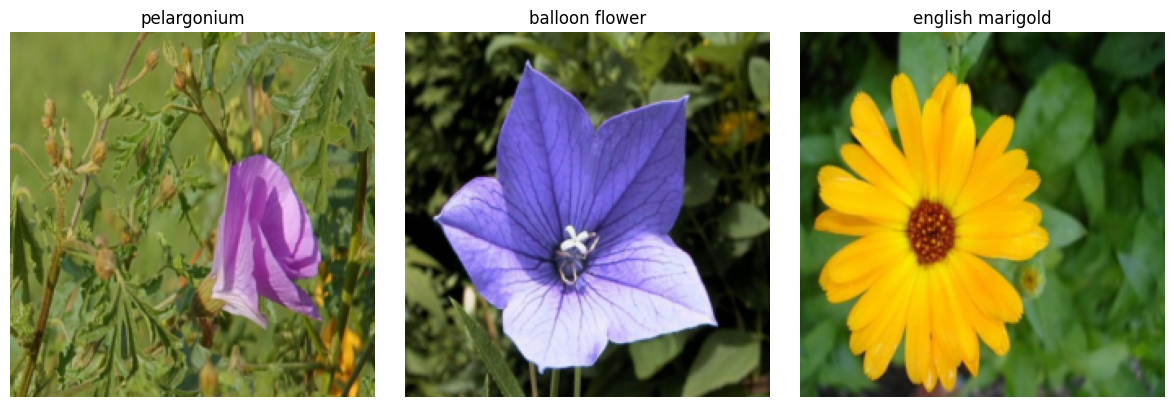

In [8]:
# Sample images with class labels
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

class_names = train_dataset.classes
indices = random.sample(range(len(train_dataset)), 3)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i, idx in enumerate(indices):
    image, label = train_dataset[idx]

    image_np = image.permute(1, 2, 0).numpy()
    image_np = image_np * std + mean
    image_np = np.clip(image_np, 0, 1)

    axes[i].imshow(image_np)
    axes[i].set_title(class_names[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Data Pipeline

A data pipeline is created to load the dataset in batches, improving training efficiency and memory usage.

PyTorch’s `DataLoader` is used to handle batching, shuffling, and data loading. The training dataset is shuffled to improve generalization, while the validation and test datasets are kept unshuffled for consistent evaluation.

In [9]:
# Batch size
batch_size = 32

# Training samples
num_train_samples = len(train_dataset)
print(f"Training samples: {num_train_samples}")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Training samples: 1020


## Model Training

A pretrained MobileNetV2 model is used for image classification through transfer learning. Instead of training from scratch, the feature extraction layers are kept fixed while the final classifier is replaced and trained on the flower dataset.

The training process includes:

- Loading a pretrained MobileNetV2 model  
- Freezing feature extraction layers  
- Replacing the final classifier layer  
- Training on the flower dataset  
- Monitoring training and validation performance  
- Saving the trained model  

This approach reduces training time and improves performance, especially with limited training data.

In [10]:
# Set device (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained MobileNetV2
model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier for current task
model.classifier[1] = nn.Linear(model.last_channel, num_classes)

# Move to device
model = model.to(device)

In [11]:
# Display model architecture and parameter details
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV2                                        [1, 102]                  --
├─Sequential: 1-1                                  [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 32, 112, 112]         (864)
│    │    └─BatchNorm2d: 3-2                       [1, 32, 112, 112]         (64)
│    │    └─ReLU6: 3-3                             [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 112, 112]         --
│    │    └─Sequential: 3-4                        [1, 16, 112, 112]         (896)
│    └─InvertedResidual: 2-3                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-5                        [1, 24, 56, 56]           (5,136)
│    └─InvertedResidual: 2-4                       [1, 24, 56, 56]           --
│    │    └─Sequential

In [12]:
from tqdm import tqdm

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters())

# Tracking metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

EPOCHS = 15

model.to(device)

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = correct_train / total_train

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct_val / total_val

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/15: 100%|██████████| 32/32 [01:18<00:00,  2.44s/it]


Epoch 1/15 | Train Loss: 4.4516 | Train Acc: 0.0990 | Val Loss: 3.8141 | Val Acc: 0.5127


Epoch 2/15: 100%|██████████| 32/32 [01:04<00:00,  2.00s/it]


Epoch 2/15 | Train Loss: 3.2008 | Train Acc: 0.7775 | Val Loss: 3.0682 | Val Acc: 0.6990


Epoch 3/15: 100%|██████████| 32/32 [01:21<00:00,  2.55s/it]


...

Epoch 13/15 | Train Loss: 0.2468 | Train Acc: 0.9990 | Val Loss: 1.0771 | Val Acc: 0.8216


Epoch 14/15: 100%|██████████| 32/32 [01:17<00:00,  2.42s/it]


Epoch 14/15 | Train Loss: 0.2147 | Train Acc: 1.0000 | Val Loss: 1.0589 | Val Acc: 0.8206


Epoch 15/15: 100%|██████████| 32/32 [00:50<00:00,  1.58s/it]


Epoch 15/15 | Train Loss: 0.1865 | Train Acc: 1.0000 | Val Loss: 1.0220 | Val Acc: 0.8147


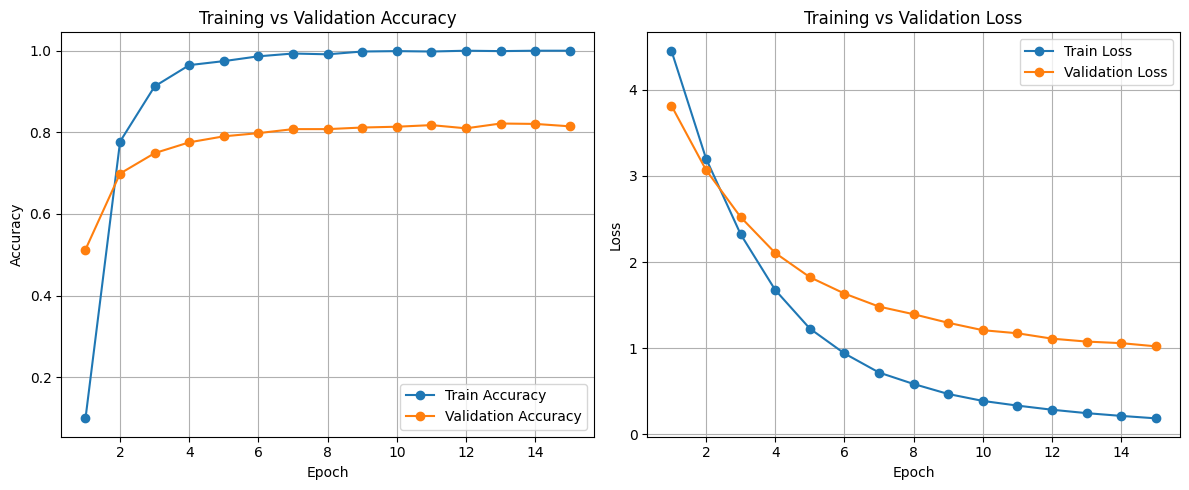

In [13]:
# Plot training results
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
axes[0].plot(epochs_range, train_accuracies, marker='o', label="Train Accuracy")
axes[0].plot(epochs_range, val_accuracies, marker='o', label="Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Training vs Validation Accuracy")
axes[0].grid(True)
axes[0].legend()

# Loss
axes[1].plot(epochs_range, train_losses, marker='o', label="Train Loss")
axes[1].plot(epochs_range, val_losses, marker='o', label="Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Training vs Validation Loss")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

## Model Evaluation

The trained model is evaluated on the test dataset, which contains images not seen during training or validation. This provides an unbiased measure of how well the model generalizes to new data.

The evaluation is based on classification accuracy on the test set.

In [14]:
# Evaluate on test set
model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

# Compute metrics
test_loss /= len(test_loader)
test_accuracy = correct / total

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.3%}")


Test Loss: 1.0993
Test Accuracy: 80.924%


## Model Saving

The trained model is saved for later use in inference or further experimentation. In PyTorch, this is done by saving the model’s state dictionary, which contains the learned parameters.

This approach is efficient and allows the model to be reloaded using the same architecture and weights.

In [15]:
# Save model
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODEL_DIR / "flower_model.pth"
torch.save(model.state_dict(), model_path)

print(f"Model saved at: {model_path}")

Model saved at: ../models/flower_model.pth


## Model Loading

The saved model is loaded to perform inference or further evaluation. The model architecture is first defined, and then the saved state dictionary is loaded to restore the learned parameters.

In [16]:
# Load model
model.load_state_dict(torch.load(model_path, map_location=device))

model = model.to(device)
model.eval()

# Model summary
summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
MobileNetV2                                        [1, 102]                  --
├─Sequential: 1-1                                  [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 32, 112, 112]         (864)
│    │    └─BatchNorm2d: 3-2                       [1, 32, 112, 112]         (64)
│    │    └─ReLU6: 3-3                             [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 112, 112]         --
│    │    └─Sequential: 3-4                        [1, 16, 112, 112]         (896)
│    └─InvertedResidual: 2-3                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-5                        [1, 24, 56, 56]           (5,136)
│    └─InvertedResidual: 2-4                       [1, 24, 56, 56]           --
│    │    └─Sequential

## Inference

The trained model is used to make predictions on new images. The input image is preprocessed in the same way as the training data to ensure consistency, then passed through the model to obtain class probabilities.

The top predictions are selected based on the highest probabilities.

In [17]:
# Image preprocessing for inference
def process_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))

    image = np.array(image) / 255.0

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = (image - mean) / std

    image = torch.from_numpy(image).permute(2, 0, 1).float()
    image = image.unsqueeze(0)

    return image

## Image Preprocessing Check

In this step, the image preprocessing function is verified to ensure it works correctly.

The original image is compared with the processed image to confirm that it is properly resized and formatted before being passed to the model.

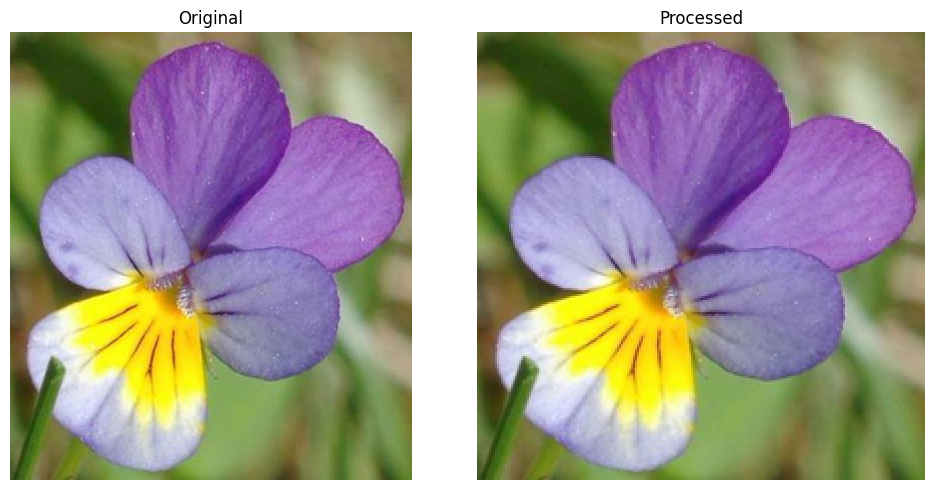

In [18]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Original vs processed image
image_path = '../test_images/wild_pansy.jpg'
original_image = np.array(Image.open(image_path).convert("RGB"))

processed_image = process_image(image_path)

image_np = processed_image.squeeze().permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

image_np = image_np * std + mean
image_np = np.clip(image_np, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original_image)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(image_np)
axes[1].set_title("Processed")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Predict top-k classes for an input image
def predict(image_path, model, top_k=5):
    top_k = max(1, top_k)

    model.eval()
    image = process_image(image_path).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)
        top_probs, top_classes = probs.topk(top_k, dim=1)

    return top_probs[0].cpu().numpy(), top_classes[0].cpu().numpy()

## Prediction Visualization

Sample images are used to verify model predictions by displaying the input alongside the top predicted classes and their probabilities.

The predictions are visualized using bar charts to show the model’s confidence, with class indices mapped to flower names for better interpretation.

In [20]:
images = [
    'cautleya_spicata.jpg',
    'hard-leaved_pocket_orchid.jpg',
    'orange_dahlia.jpg',
    'wild_pansy.jpg'
]

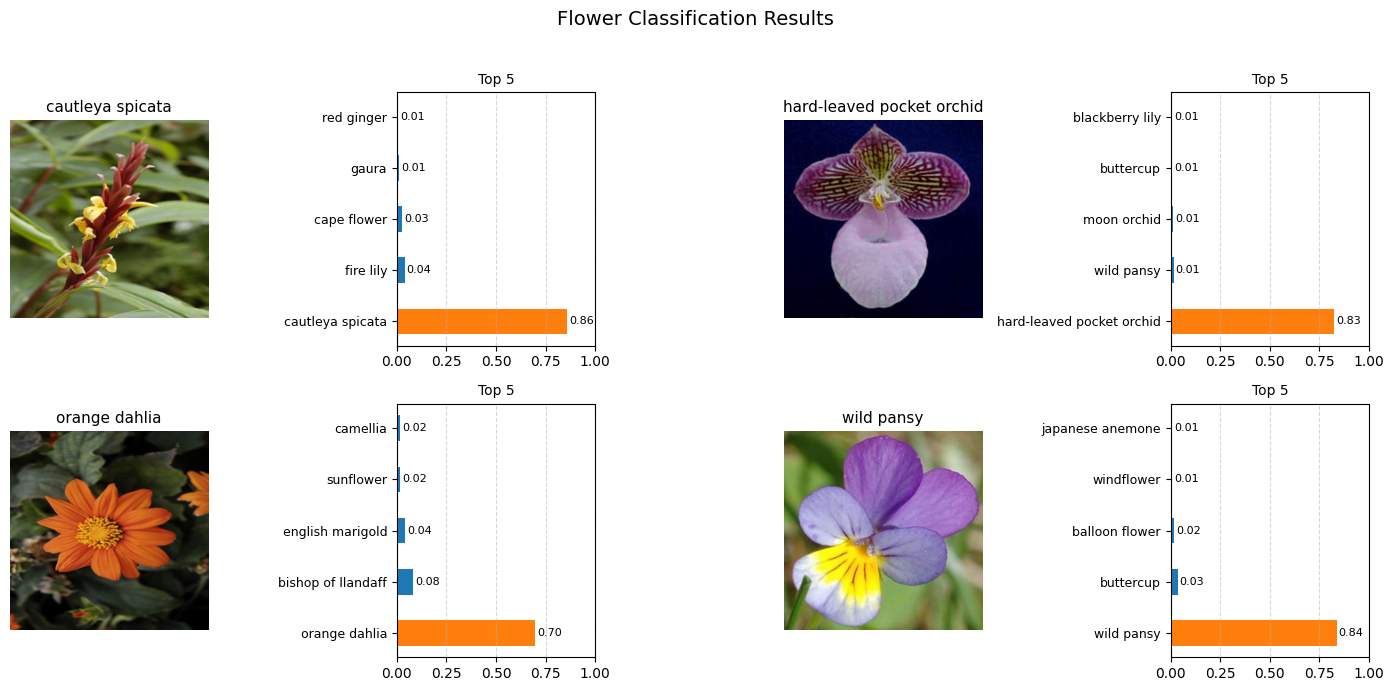

In [21]:
# Sample predictions with top-5 probabilities
images = [
    'cautleya_spicata.jpg',
    'hard-leaved_pocket_orchid.jpg',
    'orange_dahlia.jpg',
    'wild_pansy.jpg'
]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

class_names = train_dataset.classes

for i, img in enumerate(images):
    path = f'../test_images/{img}'

    probs, classes = predict(path, model, 5)
    classes = classes.astype(int)

    image = process_image(path)
    image = image.squeeze().permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    image = image * std + mean
    image = np.clip(image, 0, 1)

    flower_names = [class_names[c] for c in classes]

    row = i // 2
    col = (i % 2) * 2

    # Image
    axes[row, col].imshow(image)
    axes[row, col].set_title(flower_names[0], fontsize=11)
    axes[row, col].axis("off")

    # Top-5 probabilities
    probs_rev = probs[::-1]
    names_rev = flower_names[::-1]

    colors = ["tab:blue"] * 5
    colors[-1] = "tab:orange"

    axes[row, col + 1].barh(range(5), probs_rev, color=colors, height=0.5)
    axes[row, col + 1].set_yticks(range(5))
    axes[row, col + 1].set_yticklabels(names_rev, fontsize=9)
    axes[row, col + 1].set_xlim(0, 1)
    axes[row, col + 1].invert_yaxis()
    axes[row, col + 1].set_title("Top 5", fontsize=10)

    for j, v in enumerate(probs_rev):
        axes[row, col + 1].text(v + 0.01, j, f"{v:.2f}", va='center', fontsize=8)

    axes[row, col + 1].grid(axis='x', linestyle='--', alpha=0.5)

fig.suptitle("Flower Classification Results", fontsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("predictions_grid.png", dpi=300)
plt.show()

## Results

The model achieved a test accuracy of **81.10%**, demonstrating strong performance across 102 flower categories. The training accuracy reached near-perfect levels, indicating that the model has effectively learned the training data.

However, the gap between training and validation/test performance suggests overfitting, where the model captures training patterns more strongly than generalizable features.

## Conclusion

This project implements a complete image classification pipeline using transfer learning with MobileNetV2, covering data preprocessing, model training, evaluation, and inference.

The results highlight both the strength and limitations of transfer learning on limited data. To improve generalization, further optimization can include fine-tuning deeper layers, applying data augmentation, and introducing regularization techniques such as dropout or weight decay.